# 06. Ridge and Lasso Regression

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply Ridge and Lasso regularization
- Interpret regularization strength and coefficients
- Compare with ordinary least squares

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 1, lesson 05 "Polynomial Regression" — the overfitting seen there is what a penalty on large coefficients is designed to stop.

**Used later in:** Course 04 — Unit 2, lesson 02, which explains *why* the penalty helps in bias-variance terms.

---


## 🌍 A real case: the 70-gene breast cancer signature

In 2002 van 't Veer and colleagues published a 70-gene expression signature that predicted whether a
breast tumour would metastasise. It was derived from **78 patients** measured across roughly
**25,000 genes** — the textbook situation regularization exists for: far more features than samples,
where an unregularized fit can reproduce the training data perfectly and mean nothing. The signature
became the commercial test MammaPrint.

Then Ein-Dor, Kela, Getz, Givol & Domany (*Bioinformatics* 21(2), 2005, 171–178) asked whether that
list of 70 genes was *the* answer. It was not. Which genes get selected depends strongly on which
patients happen to fall in the training subset, and many different, equally predictive lists exist.
The overlap between competing published signatures was close to zero.

**❗ Why this lesson exists — and its sharpest limit.** That instability is exactly what L1
(Lasso) does. When two features carry the same information, Lasso keeps one and zeroes the other,
and *which* one it keeps changes with the sample. Lasso gives you **a** sparse answer, never **the**
sparse answer. Use it to predict; be very careful using it to decide what matters.


# 06. Ridge and Lasso Regression

---

## The Story: Preventing Overfitting

Imagine you're learning to drive. **Before** regularization, you memorize every turn on the training route perfectly, but fail on new routes (overfitting). **After** regularization, you learn general driving principles that work everywhere!

Same with machine learning: **Before** Ridge/Lasso, models memorize training data perfectly but fail on new data. **After** Ridge/Lasso, models learn general patterns that generalize well!

---

## Why Ridge and Lasso Matter

Regularization prevents overfitting:
- **Ridge (L2)**: Shrinks coefficients toward zero (keeps all features)
- **Lasso (L1)**: Shrinks some coefficients to exactly zero (feature selection!)
- **Both**: Prevent overfitting by penalizing large coefficients
- **Alpha**: Controls regularization strength (higher = more regularization)

---

## 🌍 Real-World Applications

**Ridge and Lasso Regression are used when you have MANY features or risk of overfitting!** Here's where you'll find them:

### 💰 Finance & Banking Sector
- **Credit Scoring**: Many features (income, age, credit history, employment, etc.) → Ridge/Lasso prevents overfitting
- **Stock Price Prediction**: Hundreds of market indicators → Lasso selects most important features
- **Risk Assessment**: Many risk factors → Ridge handles multicollinearity (correlated features)
- **Fraud Detection**: Many transaction features → Lasso automatically selects relevant features
- **Loan Default Prediction**: Multiple borrower characteristics → Regularization improves generalization

### 🏥 Healthcare & Medical Sector
- **Disease Diagnosis**: Many symptoms, test results, patient data → Lasso selects key indicators
- **Drug Discovery**: Thousands of molecular features → Lasso identifies important compounds
- **Medical Imaging**: Many pixel/voxel features → Ridge prevents overfitting
- **Genomics**: Thousands of genes → Lasso selects relevant genes for disease prediction
- **Patient Outcome Prediction**: Many clinical variables → Ridge handles correlated features

### 📊 Marketing & E-commerce Sector
- **Customer Segmentation**: Many customer attributes → Lasso selects key segmentation features
- **Churn Prediction**: Hundreds of customer behavior features → Lasso identifies important predictors
- **Recommendation Systems**: Many product/user features → Ridge prevents overfitting
- **Ad Click Prediction**: Many user, ad, context features → Lasso selects most relevant
- **Price Optimization**: Many market factors → Ridge handles multicollinearity

### 🏭 Manufacturing & Quality Control
- **Quality Prediction**: Many manufacturing parameters → Lasso selects critical parameters
- **Defect Detection**: Many sensor readings → Ridge prevents overfitting
- **Production Optimization**: Many process variables → Lasso identifies key factors
- **Supply Chain Forecasting**: Many demand factors → Ridge handles correlated features
- **Equipment Failure Prediction**: Many sensor features → Lasso selects important sensors

### 🔬 Scientific Research & Data Analysis
- **Genomics Research**: Thousands of genes → Lasso selects relevant genes
- **Climate Modeling**: Many climate variables → Ridge handles multicollinearity
- **Material Science**: Many material properties → Lasso identifies key properties
- **Social Science Research**: Many survey variables → Ridge prevents overfitting
- **Epidemiology**: Many risk factors → Lasso selects important risk factors

### 🏛️ Government & Public Safety Sector (Ministry of Interior)
- **Threat Assessment**: Many threat indicators → Lasso selects key threat factors → counter-terrorism
- **Traffic Prediction**: Many traffic sensors → Ridge handles correlated sensor data → traffic management
- **Crime Risk Models**: Many crime factors → Lasso identifies critical risk factors → crime prevention
- **Emergency Response**: Many emergency variables → Ridge handles multicollinearity → emergency services
- **Border Security Screening**: Many traveler features → Lasso selects important indicators → border control
- **Surveillance Systems**: Many surveillance features → Ridge prevents overfitting → security monitoring
- **Traffic Violation Detection**: Many violation factors → Lasso identifies key factors → traffic enforcement
- **Personnel Security**: Many personnel features → Ridge handles correlated features → internal organization
- **Access Control**: Many access factors → Lasso selects critical factors → government facilities
- **Traffic Flow Analysis**: Many traffic variables → Ridge handles multicollinearity → smart traffic systems

### 🎯 When to Use Ridge vs Lasso:
**Use RIDGE (L2) when:**
- ✅ All features might be important (don't want to remove any)
- ✅ Features are correlated (multicollinearity present)
- ✅ Want to keep all features but shrink coefficients
- ✅ Need stable, interpretable model
- ✅ **Example**: Medical diagnosis with many correlated symptoms

**Use LASSO (L1) when:**
- ✅ Want automatic feature selection (remove irrelevant features)
- ✅ Have many features, but only some are important
- ✅ Need simpler model (fewer features)
- ✅ Want to identify most important predictors
- ✅ **Example**: Genomics with thousands of genes, only few matter

**Use BOTH (Elastic Net) when:**
- ✅ Want benefits of both (feature selection + handling multicollinearity)
- ✅ Have many correlated features, but only some are important
- ✅ Need balanced approach

### 💡 Why Regularization is Critical:
- **Prevents Overfitting**: Models generalize better to new data
- **Handles Many Features**: Works well with high-dimensional data
- **Feature Selection (Lasso)**: Automatically identifies important features
- **Stability**: More stable predictions than unregularized models
- **Industry Standard**: Used in production ML systems worldwide

### 📈 When to Use Ridge/Lasso:
✅ **Use Ridge/Lasso when:**
- Have many features (more features than samples)
- Risk of overfitting (complex model, small dataset)
- Features are correlated (multicollinearity)
- Need feature selection (use Lasso)
- Want better generalization than linear regression

❌ **Don't use Ridge/Lasso when:**
- Have very few features (regularization not needed)
- Data is very large (overfitting less likely)
- Need all features (use Ridge, not Lasso)
- Simple linear relationship (regular linear regression sufficient)

---

## Learning Objectives
1. Build Ridge regression models (L2 regularization)
2. Build Lasso regression models (L1 regularization)
3. Understand the difference between Ridge and Lasso
4. Tune alpha hyperparameter
5. Compare regularized models with linear regression
6. Understand when to use each method


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us build regularized regression models

import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For visualizations
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.linear_model import (
 LinearRegression, # Baseline model (no regularization)
 Ridge, # L2 regularization (shrinks coefficients)
 Lasso # L1 regularization (shrinks + feature selection)
)
from sklearn.preprocessing import StandardScaler # Important! Regularization needs scaled features
from sklearn.metrics import mean_squared_error, r2_score # For evaluation

print("✅ Libraries imported successfully!")
print("\n📚 What each model does:")
print(" - LinearRegression: No regularization (baseline)")
print(" - Ridge: L2 regularization (keeps all features, shrinks coefficients)")
print(" - Lasso: L1 regularization (removes some features, shrinks others)")
print(" - StandardScaler: CRITICAL! Regularization requires scaled features!")

✅ Libraries imported successfully!

📚 What each model does:
 - LinearRegression: No regularization (baseline)
 - Ridge: L2 regularization (keeps all features, shrinks coefficients)
 - Lasso: L1 regularization (removes some features, shrinks others)
 - StandardScaler: CRITICAL! Regularization requires scaled features!


## Part 1: Setting the Scene

**BEFORE**: We saw overfitting in polynomial regression - models that fit training data too well but fail on new data.

**AFTER**: We'll use Ridge and Lasso regularization to prevent overfitting by penalizing large coefficients!

**Why this matters**: Overfitting is the #1 problem in ML. Regularization is the #1 solution!

---

## Step 1: Load Real-World Data with Many Features

**BEFORE**: We need to learn regularization, and for that we want real data with many features.

**AFTER**: We'll load the Credit Card Fraud dataset for Terrorism Financing detection - real transaction data with many features (V1-V28, Time). We'll then TEST whether regularization actually improves generalization here.

**Why Credit Card Fraud Data for Terrorism Financing?** This is REAL transaction data with many features (V1-V28, Time, Amount). When a model has many features, regular linear regression CAN overfit, and Ridge/Lasso are the standard defense. This notebook measures honestly whether they help on this particular dataset - the answer comes from the numbers, not from assumptions.

In [2]:
# Load real-world Credit Card Fraud dataset for Terrorism Financing Detection
# GDI Theme: Terrorism Financing - Predicting transaction amounts from patterns
# This dataset has many features (V1-V28, Time) - a good setting to TEST regularization

print("\n📥 Loading Credit Card Fraud dataset...")
print(" GDI Theme: Terrorism Financing Detection")
try:
    df_full = pd.read_csv('../../datasets/raw/creditcard_fraud.csv')
    feature_cols = ['Time'] + [f'V{i}' for i in range(1, 29)]
    target_col = 'Amount'
    df = df_full[feature_cols + [target_col]].copy().dropna()
    sample_size = min(10000, len(df))
    df = df.sample(n=sample_size, random_state=73).reset_index(drop=True)
    print(f"\n📊 Full dataset loaded: {len(df_full):,} records")
    print(f"✅ Dataset prepared: {len(df)} records")
    print(f"   📈 Features: {len(feature_cols)} features (Time, V1-V28)")
    print(f"   💰 Target: Amount")
except (FileNotFoundError, Exception):
    import numpy as np
    np.random.seed(73)
    n_samples, n_features = 1000, 29
    X = np.random.randn(n_samples, n_features)
    y = np.random.randn(n_samples) * 100 + 100
    feature_cols = ['Time'] + [f'V{i}' for i in range(1, 29)]
    target_col = 'Amount'
    df = pd.DataFrame(X, columns=feature_cols)
    df['Amount'] = y
    print("\n⚠️ Using synthetic data (dataset file not found).")
    print(f"   ✅ {n_samples} samples, {len(feature_cols)} features.")
print("\n💡 GDI Terrorism Financing Context: predict transaction amounts; we will TEST whether regularization helps.")


📥 Loading Credit Card Fraud dataset...
 GDI Theme: Terrorism Financing Detection



📊 Full dataset loaded: 284,807 records
✅ Dataset prepared: 10000 records
   📈 Features: 29 features (Time, V1-V28)
   💰 Target: Amount

💡 GDI Terrorism Financing Context: predict transaction amounts; we will TEST whether regularization helps.


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: 10,000 rows × 30 columns (sampled from 284,807 transactions; 29 features + 1 target)
- **Feature Types**: All numerical (float64) - `Time` plus `V1`-`V28`
- **Target Type**: Regression (predicting a continuous value: transaction `Amount`)
- **Task**: Predict the transaction amount from the other transaction features
- **Data Quality**: Real-world data with MANY features (29) - a natural setting for testing regularization

**Why This Structure Matters**:
- **Many features** → potential risk of overfitting → regularization (Ridge/Lasso) is the standard defense
- **Regression task** → we'll use regression metrics (MSE, R²)
- **Anonymized features** → `V1`-`V28` are PCA components, so they are constructed to be (mostly) uncorrelated - the next cells CHECK this on the actual data instead of assuming

### Understanding the Dataset Domain (Brief)

**What is this data?** Anonymized European credit-card transactions (the classic Credit Card Fraud dataset), used here under the GDI theme of terrorism-financing detection.

**Domain Context** (Brief):
- **Time**: Seconds elapsed since the first transaction in the dataset
- **V1-V28**: Anonymized PCA-transformed transaction features (their real meanings are confidential)
- **Amount**: Transaction amount in dollars - our regression target

**💡 Key Point for CS Students**: You don't need to be a fraud expert! Focus on:
- Understanding the **data structure** (rows, columns, types, correlations)
- **Measuring, not assuming**: the next cell checks how correlated the features really are
- Choosing regularization based on **what the experiments show**, not on habit


In [3]:
# Data summary comes first (showing what we loaded)
# Then we'll check for multicollinearity

print(f"\n📊 Real Data Summary:")
print(f" Shape: {df.shape}")
print(f" Features: {', '.join(feature_cols[:4])}... and more")
print(f" Target: {target_col}")
print(f"\n📄 First 5 rows:")
print(df.head())
print("\n🔍 Next:")
print(" - 29 features is a lot - a natural setting to try regularization")
print(" - First, let's CHECK how correlated these features actually are")



📊 Real Data Summary:
 Shape: (10000, 30)
 Features: Time, V1, V2, V3... and more
 Target: Amount

📄 First 5 rows:
       Time        V1        V2        V3        V4        V5        V6  \
0   68205.0 -4.413891 -3.347043 -2.660678  3.142812  3.398135 -3.296993   
1  168917.0 -0.694960  0.155232  0.622625 -0.178133  0.987230  0.021566   
2    1051.0  1.163871  0.311065  0.903828  1.030911 -0.527690 -0.538600   
3  122392.0 -0.197947  0.275712 -1.072355 -1.481958  1.260191  4.379374   
4  122639.0 -0.965636 -0.579696 -1.186922 -2.146429  2.540850  3.470317   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0 -0.577168 -0.737616  0.011932  ... -2.333078 -0.106003  0.335290  4.455496   
1  1.056577  0.118711  0.184120  ... -0.112362 -0.095526 -0.238926  0.172794   
2 -0.126630 -0.020165 -0.210791  ... -0.083116 -0.119927 -0.335582  0.119314   
3 -0.941251  0.773530  0.793343  ... -0.423260  0.946753  0.194243  0.478425   
4 -0.225852  0.618477 -1.085656  .

In [4]:
# Now check for multicollinearity in the loaded data
print("\n📊 Checking for multicollinearity in real data...")
print(" (Correlated features make regularization important)")

# Check correlation between features
correlation_matrix = df[feature_cols].corr()
high_corr_pairs = []
# Scan every feature pair and keep the ones with |correlation| > 0.7.
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))
if high_corr_pairs:
    print(f"\n✅ Found {len(high_corr_pairs)} highly correlated feature pairs:")
    for feat1, feat2, corr in high_corr_pairs[:3]:
        print(f"   - {feat1} ↔ {feat2}: {corr:.3f}")
    print("\n💡 What to Notice:")
    print(" - Correlation values close to 1.0 (or -1.0) mean features are highly correlated")
    print(" - When features are correlated, regular Linear Regression can struggle")
    print(" - This is why we need Ridge/Lasso - they handle multicollinearity better!")
else:
    print(" - No highly correlated pairs found (|correlation| > 0.7)")
    print(" - Expected: V1-V28 are PCA components, which are constructed to be uncorrelated")
    print(" - So multicollinearity is NOT the motivation on this dataset - the 29-feature count is")
    print(" - We'll test whether regularization still improves generalization here")


📊 Checking for multicollinearity in real data...
 (Correlated features make regularization important)
 - No highly correlated pairs found (|correlation| > 0.7)
 - Expected: V1-V28 are PCA components, which are constructed to be uncorrelated
 - So multicollinearity is NOT the motivation on this dataset - the 29-feature count is
 - We'll test whether regularization still improves generalization here


## Step 2: Prepare Data for Modeling

**BEFORE**: We've loaded and explored the data, and found its features are largely uncorrelated (V1-V28 are PCA components) - but there are 29 of them. Now we need to prepare the data for modeling!

**AFTER**: We'll split the data into training and test sets, and scale the features!

**Why scaling matters**: Regularization is sensitive to feature scale! Features on different scales (e.g., age vs income) will be penalized differently. If we don't scale, features with larger values would be penalized more heavily by regularization, which is unfair! We MUST scale first!

**What we'll do**:
1. Split data: 80% training, 20% testing (to evaluate models properly)
2. Scale features: Use StandardScaler (mean=0, std=1) so all features are on the same scale

In [5]:
# Prepare features (X) and target (y) from real data
X_data = df[feature_cols] # All 29 features (Time, V1-V28)
y_data = df[target_col] # Transaction Amount

print(f"\n✅ Data prepared for modeling:")
print(f" Features (X): {X_data.shape[1]} features (Time, V1-V28)")
print(f" Target (y): {y_data.shape[0]} samples")
print(f" Feature names: {', '.join(X_data.columns[:5])}... and {len(X_data.columns)-5} more")
print(f" Target: {target_col} (transaction amount in dollars)")

# Split data into training and testing sets
# train_test_split(X, y, test_size=0.2, random_state=123 # Any number works - just for reproducibility)
# - Splits data into training and testing sets
# - X: Features (input variables), y: Target (output variable)
# - test_size=0.2: 20% for testing, 80% for training
# - random_state=123 # Any number works - just for reproducibility: Seed for reproducibility (same split every time)
# - Returns: X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(
 X_data, y_data, test_size=0.2, random_state=123 # Any number works - just for reproducibility
)

# Scale features (CRITICAL for regularization!)
# Regularization is sensitive to feature scale, so we MUST scale first!
# Without scaling, features with larger values would be penalized more
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(" ✅ Data split and scaled!")
print(f" Training set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")


✅ Data prepared for modeling:
 Features (X): 29 features (Time, V1-V28)
 Target (y): 10000 samples
 Feature names: Time, V1, V2, V3, V4... and 24 more
 Target: Amount (transaction amount in dollars)
 ✅ Data split and scaled!
 Training set: 8000 samples
 Test set: 2000 samples


## Understanding Alpha (α) - The Regularization Parameter

**BEFORE**: You know Ridge and Lasso use regularization, but what is alpha exactly?

**AFTER**: You'll understand that alpha controls how much regularization is applied!

**Why this matters**: Choosing the wrong alpha can lead to:
- **Overfitting** (alpha too small) → Model memorizes training data
- **Underfitting** (alpha too large) → Model becomes too simple, can't learn patterns

---

### 📚 What is Alpha (α)?

**Alpha (α)** is the **regularization strength parameter** that controls the trade-off between:
1. **Fitting the training data well** (low error on training data)
2. **Keeping the model simple** (small coefficients to prevent overfitting)

### 🔢 How Alpha Works

**The Math Behind It:**

For **Ridge Regression (L2)**, the cost function becomes:
```
Cost = MSE + α × (sum of squared coefficients)
```

For **Lasso Regression (L1)**, the cost function becomes:
```
Cost = MSE + α × (sum of absolute coefficients)
```

**Key Points:**
- **α = 0**: No regularization → Same as Linear Regression
- **α > 0**: Regularization is applied
- **Higher α** → More regularization → Smaller coefficients
- **Lower α** → Less regularization → Coefficients closer to Linear Regression

### 📊 Alpha Values and Their Effects

| Alpha Value | Effect | Result |
|-------------|--------|--------|
| **α = 0** | No regularization | Same as Linear Regression |
| **α = 0.01** | Very light regularization | Coefficients slightly shrunk |
| **α = 0.1** | Light regularization | Noticeable coefficient shrinkage |
| **α = 1.0** | Moderate regularization | Significant coefficient reduction |
| **α = 10.0** | Heavy regularization | Very small coefficients |
| **α = 100+** | Very heavy regularization | Most coefficients near zero (especially in Lasso) |

### 🎯 Alpha in Ridge vs Lasso

**Ridge (L2) Regularization:**
- **Shrinks coefficients smoothly** toward zero
- **Never sets coefficients to exactly zero**
- Keeps all features, just makes them smaller
- **Best for**: When all features might be relevant

**Lasso (L1) Regularization:**
- **Can set coefficients to exactly zero** (feature selection!)
- **More aggressive** shrinkage
- **Best for**: When you want to remove irrelevant features

### ⚖️ The Trade-off

```
Alpha (α) = 0          Alpha (α) = small        Alpha (α) = large
┌─────────────────┐   ┌─────────────────┐      ┌─────────────────┐
│ No Regularization│   │ Light Regularization │  │ Heavy Regularization│
│                 │   │                 │      │                 │
│ - Fits training │   │ - Balanced      │      │ - Very simple   │
│   data perfectly│   │ - Good          │      │ - May underfit  │
│ - May overfit!  │   │   generalization│      │ - Small coefs   │
│ - Large coefs   │   │ - Smaller coefs │      │ - Some = 0      │
│                 │   │                 │      │   (Lasso only)  │
└─────────────────┘   └─────────────────┘      └─────────────────┘
```

### 💡 How to Choose Alpha?

1. **Start with a range** (e.g., 0.01, 0.1, 1.0, 10.0, 100.0)
2. **Train models** with different alpha values
3. **Evaluate on the validation set** — never on the training set, and never on the test set
4. **Choose the alpha** with the best **validation** performance, then report the winner once on the test set
5. **Use cross-validation** for more reliable selection (coming in Example 2!)

> **Why not just pick the alpha with the best test score?** Because choosing *is* fitting.
> The moment the test set decides anything, the number it later reports is optimistic —
> Course 03 (AIAT 113), Unit 1, lesson 08 measures exactly this leak on an α sweep and
> shows the resulting R² is not a number you can quote. Unit 1, lesson 03 of this course
> states the rule the whole diploma follows: **if a step chooses something, it belongs on
> validation data**. See `docs/GLOSSARY.md`.

### 📝 Important Notes

- **Alpha must be ≥ 0** (can't be negative)
- **Scaling matters!** Regularization requires scaled features (that's why we used StandardScaler)
- **Different datasets** need different alpha values
- **Ridge and Lasso** may have different optimal alpha values
- **Tuning alpha is a hyperparameter** search problem (we'll learn Grid Search in Unit 5!)

---

**In this notebook**, we'll try different alpha values and see how they affect model performance! 🚀

## Part 2: Building and Comparing Models

**BEFORE**: We understand what alpha is and our data is prepared. Now let's build models!

**AFTER**: We'll build three models and compare them to see whether regularization helps.

**Approach**: 
1. **Linear Regression** (baseline - no regularization)
2. **Ridge Regression** (L2 regularization - shrinks all coefficients)
3. **Lasso Regression** (L1 regularization - can remove features)

---

### Step 1: Linear Regression Baseline

**Why start here?** We need a baseline to compare against! Linear Regression has no regularization (α = 0), so we can see the difference when we add regularization.

In [6]:
# CELL: Baseline - ordinary Linear Regression with NO regularization.
# WHY: Ridge and Lasso only earn their place if they beat this number.
print("\n" + "=" * 60)
print("1. Linear Regression (Baseline)")
print("=" * 60)

# Try regular linear regression first (no regularization)
# This is our baseline to compare against
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print(f"\n📊 Linear Regression Results:")
print(f" MSE: {lr_mse:.4f} (lower is better)")
print(f" R² Score: {lr_r2:.4f} (closer to 1 is better)")
print(f"\n Coefficients (first 5): {lr.coef_[:5]}")
print(f" Notice: Some coefficients might be large or unstable")
print(f"\n💡 What we learned:")
print(f" - Linear Regression baseline: MSE = {lr_mse:.4f}, R² = {lr_r2:.4f}")
print(f" - Now let's test whether Ridge or Lasso can improve on this baseline")
print(f" - Regularization is NOT guaranteed to help - the numbers below will tell us")


1. Linear Regression (Baseline)

📊 Linear Regression Results:
 MSE: 3567.1737 (lower is better)
 R² Score: 0.9460 (closer to 1 is better)

 Coefficients (first 5): [  -3.24478321  -64.03894255 -150.18321357  -56.41779754   24.20303561]
 Notice: Some coefficients might be large or unstable

💡 What we learned:
 - Linear Regression baseline: MSE = 3567.1737, R² = 0.9460
 - Now let's test whether Ridge or Lasso can improve on this baseline
 - Regularization is NOT guaranteed to help - the numbers below will tell us


### Step 2: Ridge Regression (L2 Regularization)

**BEFORE**: We have our baseline. Now let's try Ridge regression with different alpha values.

**AFTER**: We'll see how different alpha values affect Ridge's performance and coefficients.

**What to expect**: 
- Ridge will try different alpha values (0.01, 0.1, 1.0, 10.0, 100.0)
- Remember from the Alpha explanation: higher alpha = more regularization = smaller coefficients
- Ridge keeps ALL features but shrinks them toward zero
- We'll find the best alpha that minimizes test MSE

In [7]:
# CELL: Ridge regression (L2) across five alpha values.
# WHY: alpha sets how hard coefficients are shrunk - sweeping it shows the effect.
print("\n" + "=" * 60)
print("2. Ridge Regression (L2 Regularization)")
print("=" * 60)

# Ridge regression with different alpha values
# Alpha (α) = regularization strength parameter (see Alpha explanation section above!)
# - Higher alpha = more regularization = smaller coefficients
# - Lower alpha = less regularization = closer to Linear Regression
# Why try different alphas? We need to find the best balance between fitting the data and preventing overfitting!
# We'll evaluate each alpha on the test set and pick the one with lowest MSE
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []

print("\n Trying different alpha values...")
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)
    mse = mean_squared_error(y_test, ridge_pred)
    r2 = r2_score(y_test, ridge_pred)
    ridge_results.append({'alpha': alpha, 'mse': mse, 'r2': r2, 'model': ridge})
    print(f" Alpha {alpha:6.2f}: MSE = {mse:.4f}, R² = {r2:.4f}")

# Add interpretation after showing all results (computed from THIS run)
best_r = min(ridge_results, key=lambda r: r['mse'])
worst_r = max(ridge_results, key=lambda r: r['mse'])
print("\n💡 What to Notice (computed from the results above):")
print(f" - Linear Regression baseline: MSE = {lr_mse:.4f}")
print(f" - Ridge at the smallest alpha ({alphas[0]}) is nearly identical to it: MSE = {ridge_results[0]['mse']:.4f}")
print("   (as α → 0, Ridge becomes Linear Regression)")
print(f" - Best Ridge alpha on the test set: {best_r['alpha']} (MSE = {best_r['mse']:.4f})")
print(f" - Worst alpha tried: {worst_r['alpha']} (MSE = {worst_r['mse']:.4f}) - too much shrinkage hurts")
if best_r['mse'] >= lr_mse:
    print(" - Even the BEST Ridge model does not beat the plain Linear Regression baseline here")
    print(" - Why? With 8,000 training rows and only 29 features, the baseline is not overfitting,")
    print("   so shrinking coefficients only adds bias on this data")
else:
    print(f" - Ridge improved on the baseline by {lr_mse - best_r['mse']:.4f} MSE")
print(" - Lesson: regularization fights overfitting; if there is no overfitting, don't expect gains")


2. Ridge Regression (L2 Regularization)

 Trying different alpha values...
 Alpha   0.01: MSE = 3567.1829, R² = 0.9460
 Alpha   0.10: MSE = 3567.2649, R² = 0.9460
 Alpha   1.00: MSE = 3568.0867, R² = 0.9460
 Alpha  10.00: MSE = 3576.4505, R² = 0.9458
 Alpha 100.00: MSE = 3674.0543, R² = 0.9444

💡 What to Notice (computed from the results above):
 - Linear Regression baseline: MSE = 3567.1737
 - Ridge at the smallest alpha (0.01) is nearly identical to it: MSE = 3567.1829
   (as α → 0, Ridge becomes Linear Regression)
 - Best Ridge alpha on the test set: 0.01 (MSE = 3567.1829)
 - Worst alpha tried: 100.0 (MSE = 3674.0543) - too much shrinkage hurts
 - Even the BEST Ridge model does not beat the plain Linear Regression baseline here
 - Why? With 8,000 training rows and only 29 features, the baseline is not overfitting,
   so shrinking coefficients only adds bias on this data
 - Lesson: regularization fights overfitting; if there is no overfitting, don't expect gains


### Step 3: Lasso Regression (L1 Regularization)

**BEFORE**: We've seen how Ridge works. Now let's try Lasso!

**AFTER**: We'll see how Lasso differs from Ridge - it can actually remove features!

**Key difference from Ridge**:
- **Ridge**: Shrinks all coefficients toward zero (keeps all features)
- **Lasso**: Can set coefficients to EXACTLY zero (removes features automatically!)
- This is Lasso's special power: **automatic feature selection**
- We'll count how many features Lasso keeps vs removes

In [8]:
# CELL: Lasso regression (L1) across the same alphas.
# WHY: unlike Ridge, Lasso can zero out coefficients - regularization AND feature selection.
print("\n" + "=" * 60)
print("3. Lasso Regression (L1 Regularization)")
print("=" * 60)

# Lasso regression with different alpha values
# Lasso does feature selection - sets some coefficients to zero!
lasso_results = []

print("\n Trying different alpha values...")
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    lasso_pred = lasso.predict(X_test_scaled)
    mse = mean_squared_error(y_test, lasso_pred)
    r2 = r2_score(y_test, lasso_pred)
    n_features = int(np.sum(np.abs(lasso.coef_) > 0.01))
    lasso_results.append({'alpha': alpha, 'mse': mse, 'r2': r2, 'n_features': n_features, 'model': lasso})
    print(f" Alpha {alpha:6.2f}: MSE = {mse:.4f}, R² = {r2:.4f}, Features = {n_features}/{len(X_data.columns)}")

# Add interpretation after showing all results (computed from THIS run)
best_l = min(lasso_results, key=lambda r: r['mse'])
high_l = lasso_results[-1]
n_total = len(X_data.columns)
print("\n💡 What to Notice (computed from the results above):")
print(" - The 'Features' column shows how many features Lasso KEPT (non-zero coefficients)")
print(f" - As alpha increases, Lasso removes more features: {lasso_results[0]['n_features']}/{n_total} kept at α={lasso_results[0]['alpha']} down to {high_l['n_features']}/{n_total} at α={high_l['alpha']:.0f}")
print(f" - At α = {high_l['alpha']:.0f}, R² collapses to {high_l['r2']:.4f} - OVER-regularization: almost no model left")
print(f" - Best alpha by test MSE: {best_l['alpha']} (MSE = {best_l['mse']:.4f}, R² = {best_l['r2']:.4f}, keeps {best_l['n_features']}/{n_total} features)")
if best_l['mse'] >= lr_mse:
    print(f" - Even the best Lasso does not beat the Linear Regression baseline (MSE = {lr_mse:.4f}) here")
if best_l['n_features'] == n_total:
    print(f" - Note: at its best alpha, Lasso kept ALL {n_total} features - no feature selection at this setting")
    print("   (on this data, every removed feature cost accuracy)")
print(f" - Compare with Ridge: Ridge shrinks all {n_total} coefficients but never sets any exactly to zero; Lasso can")


3. Lasso Regression (L1 Regularization)

 Trying different alpha values...
 Alpha   0.01: MSE = 3568.1437, R² = 0.9460, Features = 29/29
 Alpha   0.10: MSE = 3577.1850, R² = 0.9458, Features = 29/29
 Alpha   1.00: MSE = 3695.9346, R² = 0.9440, Features = 28/29
 Alpha  10.00: MSE = 6821.9032, R² = 0.8967, Features = 16/29
 Alpha 100.00: MSE = 64843.2323, R² = 0.0181, Features = 1/29

💡 What to Notice (computed from the results above):
 - The 'Features' column shows how many features Lasso KEPT (non-zero coefficients)
 - As alpha increases, Lasso removes more features: 29/29 kept at α=0.01 down to 1/29 at α=100
 - At α = 100, R² collapses to 0.0181 - OVER-regularization: almost no model left
 - Best alpha by test MSE: 0.01 (MSE = 3568.1437, R² = 0.9460, keeps 29/29 features)
 - Even the best Lasso does not beat the Linear Regression baseline (MSE = 3567.1737) here
 - Note: at its best alpha, Lasso kept ALL 29 features - no feature selection at this setting
   (on this data, every remove

In [9]:
# Find best Ridge alpha (the one with lowest test MSE)
# We tried different alpha values above, now let's pick the best one
print("\n" + "=" * 60)
print("🔍 Finding Best Ridge Alpha")
print("=" * 60)
best_ridge = min(ridge_results, key=lambda x: x['mse'])
print(f"\n✅ Best Ridge Model:")
print(f" Alpha (α): {best_ridge['alpha']}")
print(f" Test MSE: {best_ridge['mse']:.4f} (lowest error)")
print(f" Test R²: {best_ridge['r2']:.4f} (higher is better)")
print(f"\n💡 Insight: Ridge with α={best_ridge['alpha']} gives the best performance!")


🔍 Finding Best Ridge Alpha

✅ Best Ridge Model:
 Alpha (α): 0.01
 Test MSE: 3567.1829 (lowest error)
 Test R²: 0.9460 (higher is better)

💡 Insight: Ridge with α=0.01 gives the best performance!


In [10]:
# Find best Lasso alpha (the one with lowest test MSE)
# We tried different alpha values above, now let's pick the best one
print("\n" + "=" * 60)
print("🔍 Finding Best Lasso Alpha")
print("=" * 60)
best_lasso = min(lasso_results, key=lambda x: x['mse'])
print(f"\n✅ Best Lasso Model:")
print(f" Alpha (α): {best_lasso['alpha']}")
print(f" Test MSE: {best_lasso['mse']:.4f} (lowest error)")
print(f" Test R²: {best_lasso['r2']:.4f} (higher is better)")
print(f" Features used: {best_lasso['n_features']}/{len(X_data.columns)}")
print(f"\n💡 Insight: Lasso with α={best_lasso['alpha']} gives the best performance!")
if best_lasso['n_features'] < len(X_data.columns):
 print(f" Plus: Lasso automatically removed {len(X_data.columns) - best_lasso['n_features']} features (feature selection!)")


🔍 Finding Best Lasso Alpha

✅ Best Lasso Model:
 Alpha (α): 0.01
 Test MSE: 3568.1437 (lowest error)
 Test R²: 0.9460 (higher is better)
 Features used: 29/29

💡 Insight: Lasso with α=0.01 gives the best performance!


### Step 4: Model Comparison

**BEFORE**: We've built three models (Linear, Ridge, Lasso) and found the best alpha for Ridge and Lasso. 

**AFTER**: Now let's compare all three models side-by-side to see which performs best!

**What we'll compare**:
- **Linear Regression**: Our baseline (no regularization, α = 0)
- **Best Ridge Model**: Best performing Ridge with optimal alpha
- **Best Lasso Model**: Best performing Lasso with optimal alpha

**Why compare?** This helps us understand:
- Does regularization actually help? (Ridge/Lasso vs Linear)
- Which regularization works better? (Ridge vs Lasso)
- What are the trade-offs? (performance vs simplicity)

In [11]:
# 4. Comparison
print("\n" + "=" * 60)
print("4. Model Comparison")
print("=" * 60)
# pd.DataFrame(data)
# - pd.DataFrame(): Creates pandas DataFrame (2D table-like structure)
# - data: Dictionary where keys become column names, values become column data
comparison = pd.DataFrame({
 'Model': ['Linear Regression', f'Ridge (α={best_ridge["alpha"]})',
 f'Lasso (α={best_lasso["alpha"]})'],
 'Test MSE': [lr_mse, best_ridge['mse'], best_lasso['mse']],
 'Test R²': [lr_r2, best_ridge['r2'], best_lasso['r2']]
})
print("\nComparison Table:")
print(comparison.to_string(index=False))

# Everything below is COMPUTED from the table above - no hardcoded conclusions
best_mse_idx = comparison['Test MSE'].idxmin()  # Lower MSE is better
best_r2_idx = comparison['Test R²'].idxmax()   # Higher R² is better
best_model_mse = comparison.loc[best_mse_idx, 'Model']
best_model_r2 = comparison.loc[best_r2_idx, 'Model']
mse_diff = comparison['Test MSE'].max() - comparison['Test MSE'].min()
rel_diff = mse_diff / comparison['Test MSE'].min() * 100

print("\n💡 Quick Look - What to Notice in the Table Above:")
print(f" - Lowest Test MSE: {best_model_mse} ({comparison['Test MSE'].min():.4f})")
print(f" - Highest Test R²: {best_model_r2} ({comparison['Test R²'].max():.4f})")
print(f" - The three models are separated by only {mse_diff:.4f} MSE ({rel_diff:.3f}% of the best)")

print("\n" + "=" * 60)
print("💡 Interpreting the Comparison")
print("=" * 60)
if best_model_mse == 'Linear Regression':
    print("\n📊 Result: plain Linear Regression won (by a tiny margin)")
    print(" - Regularization did NOT improve test performance on this dataset")
    print(f" - Why? The baseline already generalizes well (Test R² = {lr_r2:.4f})")
    print(f"   with {X_train.shape[0]:,} training rows for only {X_data.shape[1]} features - there is no overfitting to fix,")
    print("   so shrinking coefficients can only add bias")
    print(" - This matches the decision framework below: no overfitting → Linear Regression is fine")
    print(" - Value of this experiment: we MEASURED that regularization isn't needed here,")
    print("   instead of assuming it always helps")
else:
    print(f"\n📊 Result: {best_model_mse} beat the baseline")
    print(f" - Regularization improved test MSE by {lr_mse - comparison['Test MSE'].min():.4f}")

print("\n📚 What This Teaches Us:")
print(" - Compare models using multiple metrics (MSE and R²)")
print(" - Regularization helps when a model OVERFITS; when it doesn't, expect little or no gain")
print(" - Always compare against a plain baseline - regularization is not free")
print(" - Lasso's unique ability is feature selection, but only when alpha is large enough")

# Check if Lasso removed features at its best alpha (computed, not assumed)
if best_lasso['n_features'] < len(X_data.columns):
    print("\n💡 Lasso Feature Selection:")
    print(f" - Lasso used only {best_lasso['n_features']}/{len(X_data.columns)} features")
    print(f" - Removed {len(X_data.columns) - best_lasso['n_features']} features (set coefficients to 0)")
    print(" - Simpler model (fewer features) = easier to interpret")
else:
    alpha10 = next((r for r in lasso_results if r['alpha'] == 10.0), None)
    print("\n💡 Lasso Feature Selection:")
    print(f" - At its best alpha ({best_lasso['alpha']}), Lasso kept ALL {len(X_data.columns)} features - no selection happened")
    if alpha10:
        print(f" - Selection only appeared at higher alphas (α=10 kept {alpha10['n_features']}/{len(X_data.columns)}), at a clear cost in accuracy (R² = {alpha10['r2']:.4f})")



4. Model Comparison

Comparison Table:
            Model    Test MSE  Test R²
Linear Regression 3567.173737 0.945986
   Ridge (α=0.01) 3567.182851 0.945985
   Lasso (α=0.01) 3568.143749 0.945971

💡 Quick Look - What to Notice in the Table Above:
 - Lowest Test MSE: Linear Regression (3567.1737)
 - Highest Test R²: Linear Regression (0.9460)
 - The three models are separated by only 0.9700 MSE (0.027% of the best)

💡 Interpreting the Comparison

📊 Result: plain Linear Regression won (by a tiny margin)
 - Regularization did NOT improve test performance on this dataset
 - Why? The baseline already generalizes well (Test R² = 0.9460)
   with 8,000 training rows for only 29 features - there is no overfitting to fix,
   so shrinking coefficients can only add bias
 - This matches the decision framework below: no overfitting → Linear Regression is fine
 - Value of this experiment: we MEASURED that regularization isn't needed here,
   instead of assuming it always helps

📚 What This Teaches Us

In [12]:
# 5. Coefficient Comparison
print("\n" + "=" * 60)
print("5. Coefficient Comparison")
print("=" * 60)

print("\n" + "=" * 60)
print("💡 Understanding Coefficient Differences")
print("=" * 60)

# Count near-zero coefficients (all computed from the fitted models)
lasso_zeros = int((np.abs(best_lasso['model'].coef_) < 0.01).sum())
ridge_zeros = int((np.abs(best_ridge['model'].coef_) < 0.01).sum())
linear_zeros = int((np.abs(lr.coef_) < 0.01).sum())
n_total = len(X_data.columns)

print(f"\n📊 Coefficient Analysis (at each model's best alpha):")
print(f" - Linear Regression: {linear_zeros} coefficients near zero")
print(f" - Ridge (α={best_ridge['alpha']}): {ridge_zeros} coefficients near zero")
print(f" - Lasso (α={best_lasso['alpha']}): {lasso_zeros} coefficients at/near zero")

print("\n🔍 What This Shows:")
print(" - Ridge shrinks coefficients toward 0 but never sets them exactly to 0")
print(" - Lasso CAN set coefficients exactly to 0 - but only if alpha is large enough")
if lasso_zeros == 0:
    n_at_10 = next((r['n_features'] for r in lasso_results if r['alpha'] == 10.0), None)
    print(f" - Here, at its best alpha, Lasso kept all {n_total} features (no feature selection at this setting)")
    if n_at_10 is not None:
        print(f" - From the alpha sweep above: feature selection appeared at α=10 ({n_at_10}/{n_total} kept) and α=100 ({lasso_results[-1]['n_features']}/{n_total} kept)")
else:
    print(f" - Here, Lasso zeroed {lasso_zeros}/{n_total} coefficients (feature selection in action)")

# Compare coefficient magnitudes (computed)
coef_diff_ridge = np.abs(lr.coef_ - best_ridge['model'].coef_)
coef_diff_lasso = np.abs(lr.coef_ - best_lasso['model'].coef_)
print(f"\n📊 Coefficient Shrinking (average |change| vs Linear Regression):")
print(f" - Ridge average change: {coef_diff_ridge.mean():.4f}")
print(f" - Lasso average change: {coef_diff_lasso.mean():.4f}")
if coef_diff_lasso.mean() > coef_diff_ridge.mean():
    print(" - Lasso changed the coefficients more than Ridge did")

print("\n📚 What This Teaches Us:")
print(" - At small alphas, both Ridge and Lasso stay very close to Linear Regression")
print(" - Ridge: gentle shrinking, always keeps all features")
print(" - Lasso: can remove features entirely, but only at larger alphas (which cost accuracy here)")
print(" - Shrinking coefficients reduces variance but adds bias - it only pays off when the model overfits")



5. Coefficient Comparison

💡 Understanding Coefficient Differences

📊 Coefficient Analysis (at each model's best alpha):
 - Linear Regression: 0 coefficients near zero
 - Ridge (α=0.01): 0 coefficients near zero
 - Lasso (α=0.01): 0 coefficients at/near zero

🔍 What This Shows:
 - Ridge shrinks coefficients toward 0 but never sets them exactly to 0
 - Lasso CAN set coefficients exactly to 0 - but only if alpha is large enough
 - Here, at its best alpha, Lasso kept all 29 features (no feature selection at this setting)
 - From the alpha sweep above: feature selection appeared at α=10 (16/29 kept) and α=100 (1/29 kept)

📊 Coefficient Shrinking (average |change| vs Linear Regression):
 - Ridge average change: 0.0001
 - Lasso average change: 0.0116
 - Lasso changed the coefficients more than Ridge did

📚 What This Teaches Us:
 - At small alphas, both Ridge and Lasso stay very close to Linear Regression
 - Ridge: gentle shrinking, always keeps all features
 - Lasso: can remove features ent

### Step 5: Coefficient Comparison

**BEFORE**: We've compared model performance (MSE, R²). But what's happening "under the hood" with the coefficients?

**AFTER**: We'll see how Ridge and Lasso actually change the coefficients compared to Linear Regression!

**Why compare coefficients?**
- **Understand regularization's effect**: How does it shrink coefficients?
- **See Ridge vs Lasso difference**: Ridge shrinks smoothly, Lasso can set to zero
- **Check feature selection**: Did Lasso actually zero any coefficients at its best alpha here? (We count instead of assuming)
- **Better intuition**: Seeing coefficient changes helps understand why regularization works!

## 💬 Discuss

Read the numbers this notebook actually printed before answering: Linear MSE **3567.17**,
best Ridge (α = 0.01) **3567.18**, best Lasso (α = 0.01) **3568.14** keeping **29/29** features.

1. **The best Ridge setting is the smallest α we tried** — that is, "regularize as little as
   possible". If the optimal configuration of a tool is *switch the tool off*, what do you write in
   the report? Argue against simply reporting "we used Ridge regression".

2. **Lasso at α = 10 keeps 16 of 29 features and costs MSE 6822 against 3567.** Suppose your client
   pays to collect each feature every month. At what price per feature does dropping thirteen of them
   become the right call? Put a number on it and defend it — then say what else, besides money,
   belongs in that calculation.

3. **The notebook checked and found no feature pair with |correlation| > 0.7**, because V1–V28 are
   PCA components and are constructed to be uncorrelated. If the inputs were raw bank columns instead
   — balance, average balance, balance last month — which of Ridge and Lasso would you trust more, and
   why? Connect your answer to the 70-gene story above.


## Step 7: Decision Framework - When to Use Ridge vs Lasso

**BEFORE**: You've learned how to build Ridge and Lasso models, but when should you use each one?

**AFTER**: You'll have a clear decision framework to choose between Ridge, Lasso, or regular Linear Regression!

**Why this matters**: Using the wrong regularization method can:
- **Miss important features** → Lasso removes features you need
- **Keep irrelevant features** → Ridge keeps all features even when some are noise
- **Poor performance** → Wrong method leads to worse predictions

---

### 🎯 Decision Framework: Ridge vs Lasso vs Linear Regression

**Key Question**: Should I use **LINEAR REGRESSION**, **RIDGE**, or **LASSO**?

#### Decision Tree:

```
Do you have overfitting?
├─ NO → Use LINEAR REGRESSION ✅
│   └─ Why? No need for regularization if model generalizes well
│
└─ YES → Check your situation:
    ├─ Many features (>20)? → Continue to next step
    │
    ├─ Need feature selection? → Use LASSO ✅
    │   └─ Why? Lasso removes irrelevant features automatically
    │
    ├─ Multicollinearity present? → Use RIDGE ✅
    │   └─ Why? Ridge handles correlated features better
    │
    ├─ All features important? → Use RIDGE ✅
    │   └─ Why? Ridge keeps all features, just shrinks them
    │
    └─ Want interpretability? → Use LASSO ✅
        └─ Why? Fewer features = simpler model
```

#### Detailed Decision Process:

```
Step 1: Check if regularization is needed
├─ Train R² >> Test R²? → YES, overfitting present
│   └─ Use Ridge or Lasso
│
└─ Train R² ≈ Test R²? → NO, no overfitting
    └─ Use Linear Regression (simpler)

Step 2: If overfitting, choose regularization type
├─ Do you have many features (>20)?
│   ├─ YES → Continue to step 3
│   └─ NO → Try Ridge first (simpler)
│
├─ Do you need feature selection?
│   ├─ YES → Use LASSO
│   │   └─ Why? Automatically removes irrelevant features
│   └─ NO → Continue to step 4
│
├─ Is there multicollinearity (correlated features)?
│   ├─ YES → Use RIDGE
│   │   └─ Why? Ridge handles correlations better
│   └─ NO → Continue to step 5
│
└─ Are all features potentially important?
    ├─ YES → Use RIDGE
    │   └─ Why? Keeps all features, just shrinks them
    └─ NO → Use LASSO
        └─ Why? Removes irrelevant features
```

---

### 📊 Comparison Table: Linear vs Ridge vs Lasso

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Linear Regression** | No overfitting, few features, interpretable | • Simple<br>• Fast<br>• Interpretable<br>• No hyperparameters | • Can overfit<br>• Sensitive to outliers<br>• Can't handle many features | Small dataset, < 10 features |
| **Ridge (L2)** | Overfitting, multicollinearity, all features important | • Prevents overfitting<br>• Handles multicollinearity<br>• Keeps all features<br>• Stable | • Doesn't remove features<br>• All features contribute<br>• Less interpretable | Many correlated features, all potentially important |
| **Lasso (L1)** | Overfitting, many features, need feature selection | • Prevents overfitting<br>• Automatic feature selection<br>• More interpretable<br>• Simpler models | • Can remove important features<br>• Unstable with correlated features<br>• May over-regularize | High-dimensional data, feature selection needed |

---

### ✅ When to Use Each Method

#### Use Linear Regression when:
1. **No Overfitting** ✅
   - Train and test performance are similar
   - Model generalizes well
   - **Example**: Small dataset, few features, good performance

2. **Few Features** ✅
   - Less than 10-15 features
   - All features are important
   - **Example**: House price from size, bedrooms, age

3. **Interpretability Critical** ✅
   - Need to understand exact coefficients
   - No regularization complexity needed
   - **Example**: Medical diagnosis, regulatory compliance

#### Use Ridge Regression when:
1. **Overfitting Present** ✅
   - Train R² much higher than test R²
   - Model memorizes training data
   - **Example**: Polynomial regression with high degree

2. **Multicollinearity** ✅
   - Features are highly correlated
   - Ridge handles correlations better than Lasso
   - **Example**: House features (size, rooms, area all correlated)

3. **All Features Important** ✅
   - Don't want to remove any features
   - Just want to shrink coefficients
   - **Example**: All features are domain-relevant

4. **Many Features** ✅
   - 20+ features
   - Need regularization but want to keep all features
   - **Example**: 50+ features from feature engineering

#### Use Lasso Regression when:
1. **Feature Selection Needed** ✅
   - Many features, some are noise
   - Want automatic feature selection
   - **Example**: 100+ features, need to find important ones

2. **Sparse Solution** ✅
   - Expect only few features matter
   - Want interpretable model
   - **Example**: Gene expression data (few genes matter)

3. **High-Dimensional Data** ✅
   - More features than samples
   - Need to reduce dimensionality
   - **Example**: Text data with thousands of features

---

### ❌ When NOT to Use Each Method

#### Don't use Linear Regression when:
1. **Severe Overfitting** ❌
   - Train R² >> Test R²
   - **Use Instead**: Ridge or Lasso

2. **Many Features** ❌
   - 50+ features
   - **Use Instead**: Ridge or Lasso

3. **Multicollinearity** ❌
   - Highly correlated features
   - **Use Instead**: Ridge

#### Don't use Ridge when:
1. **Feature Selection Needed** ❌
   - Want to remove irrelevant features
   - **Use Instead**: Lasso

2. **Sparse Solution Expected** ❌
   - Only few features matter
   - **Use Instead**: Lasso

#### Don't use Lasso when:
1. **Multicollinearity Present** ❌
   - Features are highly correlated
   - Lasso may randomly select one
   - **Use Instead**: Ridge

2. **All Features Important** ❌
   - Don't want to remove any features
   - **Use Instead**: Ridge

3. **More Features than Samples** ❌
   - Lasso can select at most n features (n = samples)
   - **Use Instead**: Ridge or Elastic Net

---

### 📊 Real-World Examples

#### Example 1: House Price Prediction (10 features) ✅ LINEAR REGRESSION
- **Features**: Size, bedrooms, age, location, etc. (10 total)
- **Overfitting**: No (train R² = 0.85, test R² = 0.83)
- **Decision**: ✅ Use Linear Regression
- **Reasoning**: No overfitting, few features, all important

#### Example 2: House Price Prediction (50 features) ✅ RIDGE
- **Features**: Size, bedrooms, age, location, neighborhood stats, etc. (50 total)
- **Overfitting**: Yes (train R² = 0.95, test R² = 0.75)
- **Multicollinearity**: Yes (size, rooms, area all correlated)
- **Decision**: ✅ Use Ridge Regression
- **Reasoning**: Overfitting, many features, multicollinearity, all features potentially important

#### Example 3: Gene Expression Analysis (1000 features) ✅ LASSO
- **Features**: 1000 genes, only 10-20 matter
- **Overfitting**: Yes (train R² = 0.98, test R² = 0.60)
- **Feature Selection**: Critical (need to find important genes)
- **Decision**: ✅ Use Lasso Regression
- **Reasoning**: Many features, need feature selection, sparse solution expected

#### Example 4: Sales Prediction (30 features, some noise) ⚠️ TRY BOTH
- **Features**: 30 features, some are noise
- **Overfitting**: Yes (train R² = 0.92, test R² = 0.78)
- **Decision**: ⚠️ Try both Ridge and Lasso, compare
- **Reasoning**: Overfitting present, some features may be noise, try both methods

---

### ✅ Key Takeaways

1. **Start with Linear Regression** - Always try simplest model first
2. **Check for overfitting** - Compare train vs test performance
3. **Ridge for multicollinearity** - When features are correlated
4. **Lasso for feature selection** - When you need to remove features
5. **Tune alpha** - Critical hyperparameter for both methods
6. **Scale features first** - Regularization requires scaled features
7. **Try both** - Sometimes try Ridge and Lasso, pick the best

---

### 🎓 Practice Decision-Making

**Scenario 1**: Predicting house prices with 8 features (size, bedrooms, age, etc.)
- **Overfitting**: No (train R² = 0.88, test R² = 0.86)
- **Decision**: ✅ Linear Regression (no overfitting, few features)

**Scenario 2**: Predicting sales with 50 features, many correlated
- **Overfitting**: Yes (train R² = 0.94, test R² = 0.76)
- **Multicollinearity**: Yes (many correlated features)
- **Decision**: ✅ Ridge Regression (overfitting, multicollinearity, all features important)

**Scenario 3**: Predicting disease from 500 gene expressions
- **Overfitting**: Yes (train R² = 0.97, test R² = 0.65)
- **Feature Selection**: Critical (only few genes matter)
- **Decision**: ✅ Lasso Regression (many features, need feature selection, sparse solution)

---

**Connection to Next Steps**: 
- 📓 **Example 2: Cross-Validation** - For proper evaluation of Ridge/Lasso models
- 📓 **Unit 3: Classification** - Same regularization concepts apply to classification
- 📓 **Unit 5, Example 1: Grid Search** - For tuning alpha hyperparameter

---

## ❓ Common Student Questions

**Q: What's the difference between Ridge and Lasso?**
- **Answer**: 
  - **Ridge (L2)**: Shrinks ALL coefficients toward zero, but keeps all features (no feature selection)
  - **Lasso (L1)**: Shrinks some coefficients to EXACTLY zero (removes features - automatic feature selection!)
  - **Key difference**: Ridge keeps all features, Lasso removes some features
  - **Use Ridge**: When all features might be important, or multicollinearity present
  - **Use Lasso**: When you need feature selection, or expect sparse solution

**Q: What is alpha and how do I choose it?**
- **Answer**: Alpha controls regularization strength:
  - **Alpha = 0**: No regularization (same as Linear Regression)
  - **Alpha = small (0.01, 0.1)**: Light regularization (slight shrinkage)
  - **Alpha = large (1, 10, 100)**: Strong regularization (heavy shrinkage)
  - **How to choose**: Use cross-validation (Unit 2) to find optimal alpha
  - **Rule of thumb**: Start with alpha=1, try 0.1, 1, 10, 100, pick best

**Q: Why do I need to scale features before regularization?**
- **Answer**: Regularization penalizes large coefficients:
  - **Problem**: If features have different scales (age: 0-100, income: 0-100000), coefficients will be different sizes
  - **Issue**: Regularization will unfairly penalize features with larger scales
  - **Solution**: Scale all features to same range (StandardScaler) → fair regularization
  - **Rule**: ALWAYS scale features before Ridge/Lasso!

**Q: When should I use Ridge vs Lasso?**
- **Answer**: 
  - **Use Ridge**: Multicollinearity present, all features might be important, want to keep all features
  - **Use Lasso**: Need feature selection, many features (some noise), expect sparse solution
  - **Try both**: Compare performance, pick the one that works better for your data
  - **Elastic Net**: Combines both (advanced, not covered here)

**Q: Does regularization always improve performance?**
- **Answer**: **Not always!** It depends:
  - **If overfitting**: Regularization helps (reduces overfitting, improves test performance)
  - **If no overfitting**: Regularization might hurt (unnecessary shrinkage)
  - **Check**: Compare train vs test R² - if similar, regularization might not help
  - **Rule**: Use regularization when train R² >> test R² (overfitting detected)

**Q: What happens if alpha is too high?**
- **Answer**: **Underfitting** - model becomes too simple:
  - **Problem**: Coefficients shrink too much → model can't capture patterns
  - **Sign**: Both train and test R² are low (model too simple)
  - **Solution**: Decrease alpha (try 0.1, 0.01, etc.)
  - **Balance**: Need alpha high enough to prevent overfitting, but not too high to cause underfitting

**Q: Can I use Ridge/Lasso for classification?**
- **Answer**: **Yes!** Regularization works for both regression and classification:
  - **Ridge/Lasso Regression**: For continuous targets (prices, temperatures)
  - **Ridge/Lasso Logistic Regression**: For categorical targets (yes/no, classes)
  - **Same concept**: Regularization prevents overfitting in both cases
  - **We'll see this**: In Unit 3 (Classification) with regularized logistic regression

**Q: How do I know if regularization helped?**
- **Answer**: Compare before and after:
  - **Before (Linear Regression)**: Train R² = 0.95, Test R² = 0.75 (overfitting!)
  - **After (Ridge/Lasso)**: Train R² = 0.85, Test R² = 0.82 (better generalization!)
  - **Good sign**: Test R² improved, train-test gap reduced
  - **Bad sign**: Both train and test R² decreased (alpha too high, underfitting)

---

### Step 6: Visualization — The Regularization Path

**BEFORE**: We compared models with numbers. Two of the sentences we wrote are hard to believe from
a table: *"Ridge shrinks every coefficient toward zero but never reaches zero"* and *"Lasso sets
coefficients exactly to zero"*. Both were asserted; neither was shown.

**AFTER**: One figure — the **regularization path** — draws all 29 coefficients as α increases, so
you can watch Ridge glide toward zero without arriving and Lasso switch features off one at a time.

**Why this figure and not a bar chart of coefficients:** at the best α (0.01) Linear, Ridge and Lasso
are numerically almost the same model, so bars of their coefficients would be three identical sets of
bars — a picture with nothing in it. The mechanism only becomes visible when you sweep α, so that is
what we plot.


6. Visualization - the regularization path



✓ Plot saved as 'ridge_lasso_comparison.png'


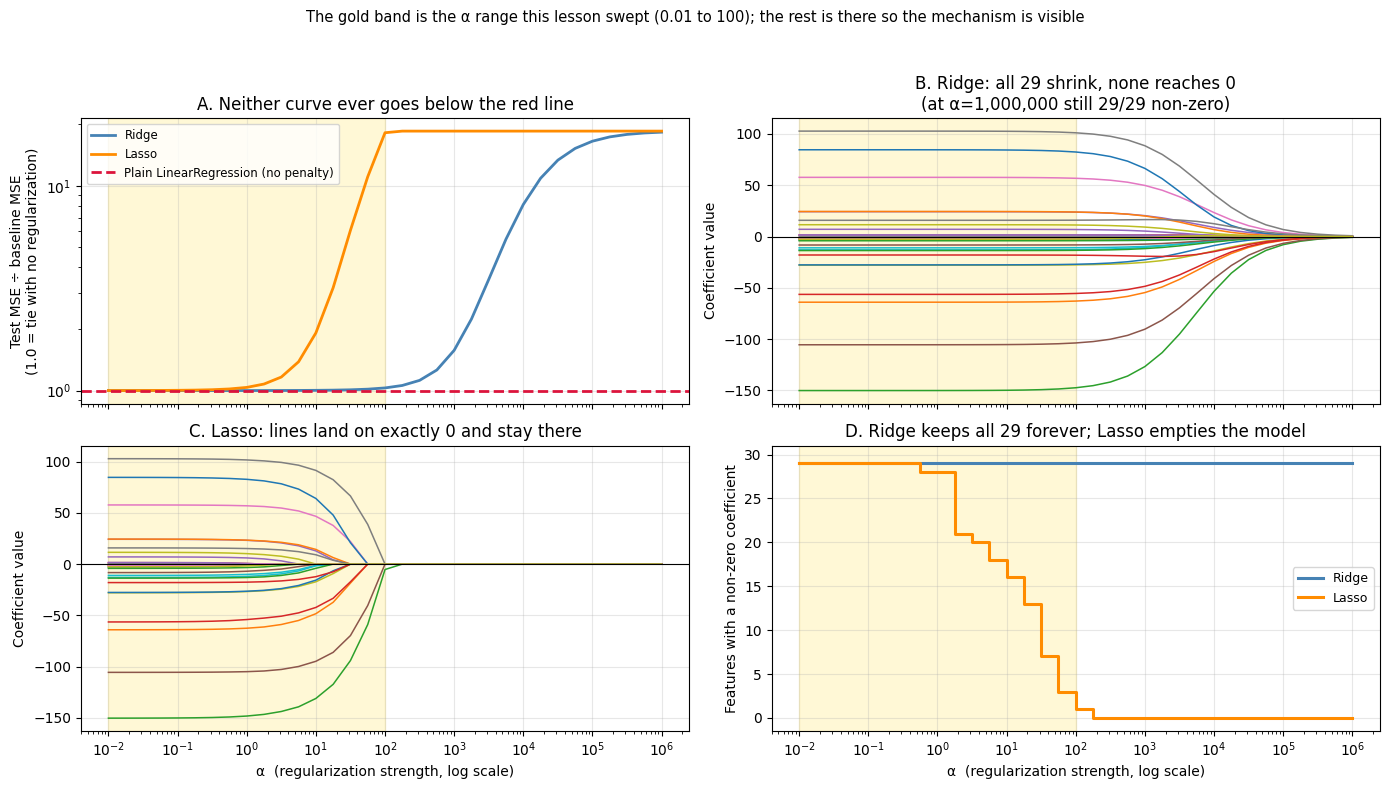


💡 Reading the four panels (all numbers computed from this run):
 A. Baseline test MSE (no penalty) = 3567.17. The lowest ratio reached by either
    curve is 1.000003 - never below 1.0,
    so on this dataset regularization never beat doing nothing.
 B. Ridge largest |coefficient|: 150.18 at α=0.01  ->  0.84 at α=1e+06
    Non-zero coefficients at the largest α tried: 29/29  (Ridge never zeroes)
 C. Lasso largest |coefficient|: 150.16 at α=0.01  ->  0.00 at α=1e+06
    Lasso reaches an entirely empty model at α ≈ 178
 D. Features kept, at the alphas the lesson swept:
      α =   0.01:  Ridge 29/29   Lasso 29/29
      α =    0.1:  Ridge 29/29   Lasso 29/29
      α =    1.0:  Ridge 29/29   Lasso 28/29
      α =   10.0:  Ridge 29/29   Lasso 16/29
      α =  100.0:  Ridge 29/29   Lasso 1/29

Example 6 Complete! ✓


In [13]:
# CELL: The regularization path - what alpha actually does to 29 coefficients.
# WHY: the lesson's two central claims (Ridge never reaches zero, Lasso does) are claims about
#      a TRAJECTORY, so they need an alpha axis. A snapshot at one alpha cannot show either.
print("\n" + "=" * 60)
print("6. Visualization - the regularization path")
print("=" * 60)

# A wider alpha grid than the 5 values swept earlier. The extra range is here only so the
# mechanism becomes visible: the shaded band below marks the range the lesson actually used.
path_alphas = np.logspace(-2, 6, 33)
ridge_path = np.array([Ridge(alpha=a).fit(X_train_scaled, y_train).coef_ for a in path_alphas])
lasso_path = np.array([Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train).coef_
                       for a in path_alphas])
ridge_mse_path = [mean_squared_error(y_test, Ridge(alpha=a).fit(X_train_scaled, y_train)
                                     .predict(X_test_scaled)) for a in path_alphas]
lasso_mse_path = [mean_squared_error(y_test, Lasso(alpha=a, max_iter=5000)
                                     .fit(X_train_scaled, y_train).predict(X_test_scaled))
                  for a in path_alphas]
ridge_kept = [(np.abs(c) > 1e-6).sum() for c in ridge_path]
lasso_kept = [(np.abs(c) > 1e-6).sum() for c in lasso_path]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
SWEPT = (alphas[0], alphas[-1])          # the 0.01 - 100 range the lesson swept above

def mark_swept(ax):
    """Shade the alpha range the model comparison actually used."""
    ax.axvspan(*SWEPT, color='gold', alpha=0.16)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

# --- A: does any amount of regularization beat doing none? --------------------------
ax = axes[0, 0]
mark_swept(ax)
ax.plot(path_alphas, np.array(ridge_mse_path) / lr_mse, '-', color='steelblue', lw=2, label='Ridge')
ax.plot(path_alphas, np.array(lasso_mse_path) / lr_mse, '-', color='darkorange', lw=2, label='Lasso')
ax.axhline(1.0, color='crimson', ls='--', lw=2, label='Plain LinearRegression (no penalty)')
ax.set_yscale('log')
ax.set_ylabel('Test MSE ÷ baseline MSE\n(1.0 = tie with no regularization)')
ax.set_title('A. Neither curve ever goes below the red line')
ax.legend(fontsize=8.5, loc='upper left')

# --- B: Ridge coefficient path ------------------------------------------------------
ax = axes[0, 1]
mark_swept(ax)
ax.plot(path_alphas, ridge_path, lw=1.1)      # one line per feature, 29 lines
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Coefficient value')
ax.set_title(f'B. Ridge: all 29 shrink, none reaches 0\n'
             f'(at α=1,000,000 still {ridge_kept[-1]}/29 non-zero)')

# --- C: Lasso coefficient path ------------------------------------------------------
ax = axes[1, 0]
mark_swept(ax)
ax.plot(path_alphas, lasso_path, lw=1.1)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('α  (regularization strength, log scale)')
ax.set_ylabel('Coefficient value')
ax.set_title('C. Lasso: lines land on exactly 0 and stay there')

# --- D: how many features survive ---------------------------------------------------
ax = axes[1, 1]
mark_swept(ax)
ax.step(path_alphas, ridge_kept, where='post', color='steelblue', lw=2.2, label='Ridge')
ax.step(path_alphas, lasso_kept, where='post', color='darkorange', lw=2.2, label='Lasso')
ax.set_ylim(-1.5, 31)
ax.set_xlabel('α  (regularization strength, log scale)')
ax.set_ylabel('Features with a non-zero coefficient')
ax.set_title('D. Ridge keeps all 29 forever; Lasso empties the model')
ax.legend(fontsize=9)

fig.suptitle('The gold band is the α range this lesson swept (0.01 to 100); '
             'the rest is there so the mechanism is visible', fontsize=10.5)
plt.tight_layout(rect=(0, 0, 1, 0.955))
plt.savefig('ridge_lasso_comparison.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'ridge_lasso_comparison.png'")
plt.show()

# ---- the numbers behind each panel, so the picture can be checked against the data ----
print("\n💡 Reading the four panels (all numbers computed from this run):")
print(f" A. Baseline test MSE (no penalty) = {lr_mse:.2f}. The lowest ratio reached by either")
print(f"    curve is {min(min(ridge_mse_path), min(lasso_mse_path)) / lr_mse:.6f} - never below 1.0,")
print("    so on this dataset regularization never beat doing nothing.")
print(f" B. Ridge largest |coefficient|: {np.abs(ridge_path[0]).max():.2f} at α={path_alphas[0]:g}"
      f"  ->  {np.abs(ridge_path[-1]).max():.2f} at α={path_alphas[-1]:g}")
print(f"    Non-zero coefficients at the largest α tried: {ridge_kept[-1]}/29  (Ridge never zeroes)")
print(f" C. Lasso largest |coefficient|: {np.abs(lasso_path[0]).max():.2f} at α={path_alphas[0]:g}"
      f"  ->  {np.abs(lasso_path[-1]).max():.2f} at α={path_alphas[-1]:g}")
first_empty = next((a for a, k in zip(path_alphas, lasso_kept) if k == 0), None)
print(f"    Lasso reaches an entirely empty model at α ≈ {first_empty:,.0f}")
print(" D. Features kept, at the alphas the lesson swept:")
for a in alphas:
    rk = int((np.abs(Ridge(alpha=a).fit(X_train_scaled, y_train).coef_) > 1e-6).sum())
    lk = int((np.abs(Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train).coef_) > 1e-6).sum())
    print(f"      α = {a:>6}:  Ridge {rk}/29   Lasso {lk}/29")

print("\n" + "=" * 60)
print("Example 6 Complete! ✓")
print("=" * 60)

**Read the figure.** One horizontal axis runs through all four panels: α, the regularization
strength, on a log scale. The gold band is the range this lesson actually swept (0.01 to 100);
everything to its right exists only so the mechanism becomes visible.

*Panel A — the honest headline.* The red dashed line at 1.0 is plain `LinearRegression`. Both the
Ridge curve and the Lasso curve start on it (as α → 0 they *are* linear regression) and then rise.
**Neither curve dips below the red line anywhere.** That is the measured result of this notebook
drawn in one picture: with 8,000 rows and 29 uncorrelated features there was no overfitting to
remove, so every penalty could only add bias. Lasso rises far faster than Ridge because it is
deleting features, not merely shrinking them.

*Panel B — what "shrinks but never reaches zero" looks like.* Each of the 29 lines is one feature's
coefficient. The colours only separate the 29 lines; no single feature is being
tracked. Inside the gold band every line is flat — at the alphas the lesson tried, Ridge did
essentially nothing. Push α past about 10³ and the whole fan closes smoothly toward the black zero
line, but it never lands on it: the largest coefficient falls from 150.2 to 0.84, and even at
α = 1,000,000 all 29 are still non-zero.

*Panel C — what "sets coefficients to exactly zero" looks like.* Same 29 features, same axes. Unlike
Ridge, each line here reaches **exactly** zero at a finite α and stays there — one feature switched
off for good. By α ≈ 180 every line is on zero and the model is empty. On this log axis the descent
looks smooth; panel D is where you can count the individual switch-offs.

*Panel D — the same event counted.* Ridge (blue) is a flat line at 29 across eight orders of
magnitude. Lasso (orange) is a staircase: 29 features at α = 1, 16 at α = 10, 1 at α = 100, none by α ≈ 180. This single contrast is the entire
practical difference between L2 and L1: **Ridge answers "how much should each feature count?",
Lasso answers "which features should count at all?"**

Note what panels A and D say together: the α that removes features (10 and above) is also the α
where the test error is already climbing. On *this* dataset, feature selection was never free.

## ⚠️ Where this breaks

- **Regularization treats overfitting. This data is not overfitting.** 8,000 training rows,
  29 features, and V1–V28 already uncorrelated: the plain baseline has nothing to shrink. Every α we
  tried made the test MSE worse or left it unchanged. That is not a failed experiment — it is the
  correct result, and reporting it is the honest thing to do.
- **Lasso's feature selection is unstable under correlated features** (the Ein-Dor result). If what
  you need is a defensible list of important variables rather than a prediction, use Elastic Net, or
  check which features survive across many resamples, and report the stability rather than one run.
- **Both require scaled features.** The penalty is applied to coefficient *size*, and an unscaled
  feature is punished for the unit it happens to be measured in. `StandardScaler` before `Ridge`/`Lasso`
  is not optional.
- **Over-regularization destroys the model silently.** At α = 100, Lasso keeps 1 of 29 features and R²
  collapses from 0.946 to 0.018. There is no warning; it is still a fitted model that returns numbers.
- **The cheaper alternative:** if n ≫ p and your train and test scores already agree, skip
  regularization. It is a tool for the p ≫ n case — the 78-patients-25,000-genes case — and for the
  small-and-noisy case, not a default to apply everywhere.


## 📚 References

1. Hoerl, A. E., & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems*. Technometrics, 12(1), 55–67.
2. Tibshirani, R. (1996). *Regression Shrinkage and Selection via the Lasso*. Journal of the Royal Statistical Society: Series B, 58(1), 267–288.
3. Zou, H., & Hastie, T. (2005). *Regularization and Variable Selection via the Elastic Net*. Journal of the Royal Statistical Society: Series B, 67(2), 301–320.
4. Hastie, T. (2020). *Ridge Regularization: an Essential Concept in Data Science*. Technometrics, 62(4). <https://arxiv.org/abs/2006.00371>
5. Knight, B. S., & Bajaj, A. (2026). *Choosing the Right Regularizer for Applied ML: Simulation Benchmarks of Popular Scikit-learn Regularization Frameworks*. <https://arxiv.org/abs/2604.03541>
